## Test Python

In [1]:
print("Hello World")

Hello World


## Import All Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

# BAB IV
## Analisis dan Perancangan

## 4.1 Dataset

## Import Dataset

In [5]:
import pandas as pd

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv")
df.head()

,age;experience_years;daily_work_hours;sleep_hours;caffeine_intake;bugs_per_day;commits_per_day;meetings_per_day;screen_time;exercise_hours;burnout_level
0,26.0;12.0;10.33;4.45;2.0;11.0;4.0;1.0;15.07;0....
1,39.0;10.0;8.62;5.77;5.0;15.0;11.0;5.0;13.25;0....
2,34.0;13.0;;4.03;5.0;2.0;18.0;9.0;11.18;1.54;Me...
3,30.0;1.0;6.85;6.47;2.0;15.0;26.0;1.0;11.14;0.9...
4,27.0;7.0;4.24;5.8;;9.0;17.0;7.0;8.05;0.36;Low


## Load Dataset

In [6]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan dimensi awal sebelum dibersihkan
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom")
print("\n=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===")
print(df.isnull().sum())

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
burnout_level       140
dtype: int64


## Read Dataset

In [7]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan informasi dimensi awal
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom\n")

# ==========================================================
# 3. MENAMPILKAN DISTRIBUSI KELAS TARGET (TERMASUK DATA HILANG)
# ==========================================================
print("=== DISTRIBUSI KELAS TARGET ===")
nama_kolom_target = 'burnout_level'

if nama_kolom_target in df.columns:
    # Menggunakan dropna=False agar data NaN/Kosong dipaksa muncul
    distribusi = df[nama_kolom_target].value_counts(dropna=False)
    
    for label, jumlah in distribusi.items():
        # Memeriksa apakah baris tersebut merupakan data kosong (NaN)
        if pd.isna(label):
            print(f"Jumlah Data KOSONG (Missing/NaN) : {jumlah} baris  <-- 🔍 TARGET YANG HILANG!")
        else:
            print(f"Jumlah Data {label:<20} : {jumlah} baris")
            
    print("-" * 50)
    print(f"TOTAL KESELURUHAN DATASET        : {distribusi.sum()} baris (Pas 7000!)")
else:
    print(f"Peringatan: Kolom '{nama_kolom_target}' tidak ditemukan!")

print("-" * 50)
print("\n")

# ==========================================================
# 4. MENAMPILKAN MISSING VALUES UNTUK SETIAP FITUR / VARIABEL
# ==========================================================
print("=== PENCEKAN MISSING VALUES PER VARIABEL ===")
# Hitung missing value di setiap kolom
missing_per_kolom = df.isnull().sum()

for kolom, jumlah_missing in missing_per_kolom.items():
    if jumlah_missing > 0:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong <-- ⚠️ Perlu Imputasi/Cleaning")
    else:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong (Bersih)")

print("-" * 50)

# Kesimpulan untuk bahan narasi Bab IV Skripsi
print("\n💡 CATATAN ANALISIS UNTUK BAB IV (PREPROCESSING):")
print(f"- Kolom target '{nama_kolom_target}' memiliki {df[nama_kolom_target].isnull().sum()} data kosong yang wajib DIBUANG (Drop Row).")
print("- Fitur-fitur numerik lainnya yang memiliki data kosong nanti akan diatasi pada tahap")
print("  preprocessing menggunakan Nilai Median (Imputasi Median) sebelum masuk ke pemodelan.")
print("="*50)

# ==========================================================
# 5. PREVIEW DATASET INTERAKTIF
# ==========================================================
df

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== DISTRIBUSI KELAS TARGET ===
Jumlah Data Medium               : 3485 baris
Jumlah Data High                 : 1782 baris
Jumlah Data Low                  : 1593 baris
Jumlah Data KOSONG (Missing/NaN) : 140 baris  <-- 🔍 TARGET YANG HILANG!
--------------------------------------------------
TOTAL KESELURUHAN DATASET        : 7000 baris (Pas 7000!)
--------------------------------------------------


=== PENCEKAN MISSING VALUES PER VARIABEL ===
Variabel age                  : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel experience_years     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel daily_work_hours     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel sleep_hours          : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel caffeine_intake      : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel bugs_per_day         : 140

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,Low
...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,Medium


## Split Data

SPLIT DATA TRAINING DAN TESTING
Total data awal : 7000
Total data setelah filter usia 20-35 tahun : 4328
------------------------------------------------------------
Data Seluruh  : 4328
Data Training : 3462
Data Testing  : 866
------------------------------------------------------------
Data seluruh berhasil disimpan
Data training berhasil disimpan
Data testing berhasil disimpan

Lokasi penyimpanan:
../hasil/3_data_seluruh.csv
../hasil/3_data_training.csv
../hasil/3_data_testing.csv


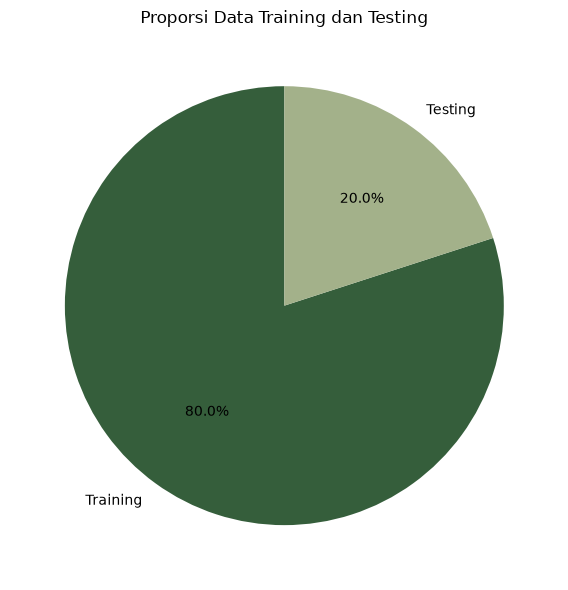

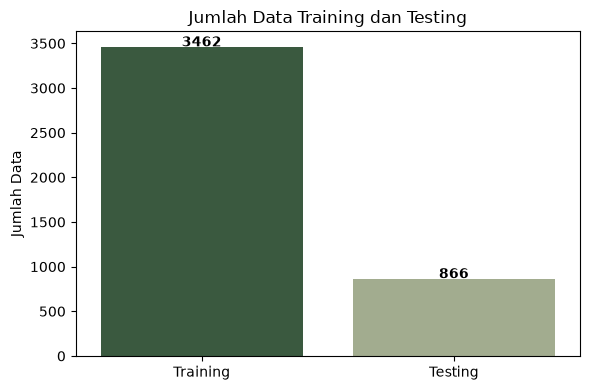

SPLIT DATA BERHASIL


In [10]:
# ==========================================================
# SPLIT DATA TRAINING DAN TESTING + FILTER USIA
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("="*60)
print("SPLIT DATA TRAINING DAN TESTING")
print("="*60)

# ==========================================================
# MEMBACA DATASET
# ==========================================================

df = pd.read_csv(
    "../dataset/developer_burnout_dataset_ervin.csv",
    delimiter=";"
)

print(f"Total data awal : {len(df)}")

# ==========================================================
# FILTER USIA 20 - 35 TAHUN
# ==========================================================

df = df[
    (df["age"] >= 20) &
    (df["age"] <= 35)
].copy()

print(f"Total data setelah filter usia 20-35 tahun : {len(df)}")

# ==========================================================
# SPLIT DATA
# ==========================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("-"*60)
print(f"Data Seluruh  : {len(df)}")
print(f"Data Training : {len(df_train)}")
print(f"Data Testing  : {len(df_test)}")
print("-"*60)

# ==========================================================
# MEMBUAT FOLDER HASIL
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

# ==========================================================
# SIMPAN DATA
# ==========================================================

# Seluruh data setelah filter usia
df.to_csv(
    "../hasil/3_data_seluruh.csv",
    index=False
)

# Data training
df_train.to_csv(
    "../hasil/3_data_training.csv",
    index=False
)

# Data testing
df_test.to_csv(
    "../hasil/3_data_testing.csv",
    index=False
)

print("Data seluruh berhasil disimpan")
print("Data training berhasil disimpan")
print("Data testing berhasil disimpan")

print("\nLokasi penyimpanan:")
print("../hasil/3_data_seluruh.csv")
print("../hasil/3_data_training.csv")
print("../hasil/3_data_testing.csv")

# ==========================================================
# GRAFIK PROPORSI TRAIN TEST
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    [len(df_train), len(df_test)],
    labels=["Training","Testing"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#355E3B","#A3B18A"]
)

plt.title("Proporsi Data Training dan Testing")

plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIK JUMLAH DATA
# ==========================================================

visual = pd.DataFrame({
    "Jenis Data": [
        "Training",
        "Testing"
    ],
    "Jumlah": [
        len(df_train),
        len(df_test)
    ]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=visual,
    x="Jenis Data",
    y="Jumlah",
    hue="Jenis Data",
    palette=["#355E3B","#A3B18A"],
    legend=False
)

for p in ax.patches:

    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()+5
        ),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Jumlah Data Training dan Testing")
plt.ylabel("Jumlah Data")
plt.xlabel("")

plt.tight_layout()
plt.show()

print("="*60)
print("SPLIT DATA BERHASIL")
print("="*60)

## Preprocessing
## Eksperimen

## 1. Handling Missing Value

In [11]:
# ==========================================================
# HANDLING MISSING VALUE
# ==========================================================

import os
import pandas as pd
import numpy as np

print("="*60)
print("HANDLING MISSING VALUE")
print("="*60)

# ==========================================================
# MEMBACA DATA TRAIN DAN TEST
# ==========================================================

df_train = pd.read_csv("../hasil/3_data_training.csv")
df_test = pd.read_csv("../hasil/3_data_testing.csv")

print("\nJumlah Data Training :", len(df_train))
print("Jumlah Data Testing  :", len(df_test))

# ==========================================================
# CEK MISSING VALUE SEBELUM IMPUTASI
# ==========================================================

print("\nMissing Value Data Training")
print(df_train.isnull().sum())

print("\nMissing Value Data Testing")
print(df_test.isnull().sum())

# ==========================================================
# IMPUTASI DATA NUMERIK
# (Median dari Data Training)
# ==========================================================

numeric_cols = df_train.select_dtypes(include=np.number).columns

for col in numeric_cols:

    median = df_train[col].median()

    df_train[col] = df_train[col].fillna(median)
    df_test[col] = df_test[col].fillna(median)

# ==========================================================
# IMPUTASI DATA KATEGORIK
# (Modus dari Data Training)
# ==========================================================

categorical_cols = df_train.select_dtypes(include="object").columns

for col in categorical_cols:

    mode_value = df_train[col].mode()[0]

    df_train[col] = df_train[col].fillna(mode_value)
    df_test[col] = df_test[col].fillna(mode_value)

# ==========================================================
# VERIFIKASI
# ==========================================================

print("\nMissing Value Setelah Imputasi (Training)")
print(df_train.isnull().sum())

print("\nMissing Value Setelah Imputasi (Testing)")
print(df_test.isnull().sum())

print("\nTotal Missing Value Training :", df_train.isnull().sum().sum())
print("Total Missing Value Testing  :", df_test.isnull().sum().sum())

# ==========================================================
# SIMPAN HASIL
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

df_train.to_csv("../hasil/1_data_training_bersih.csv", index=False)
df_test.to_csv("../hasil/1_data_testing_bersih.csv", index=False)

print("\nData training bersih berhasil disimpan")
print("../hasil/1_data_training_bersih.csv")

print("\nData testing bersih berhasil disimpan")
print("../hasil/1_data_testing_bersih.csv")

print("="*60)
print("HANDLING MISSING VALUE SELESAI")
print("="*60)

HANDLING MISSING VALUE

Jumlah Data Training : 3462
Jumlah Data Testing  : 866

Missing Value Data Training
age                  0
experience_years    85
daily_work_hours    71
sleep_hours         71
caffeine_intake     75
bugs_per_day        66
commits_per_day     64
meetings_per_day    62
screen_time         73
exercise_hours      64
burnout_level       72
dtype: int64

Missing Value Data Testing
age                  0
experience_years    15
daily_work_hours    22
sleep_hours         20
caffeine_intake     18
bugs_per_day        14
commits_per_day     15
meetings_per_day    19
screen_time         15
exercise_hours      23
burnout_level       13
dtype: int64

Missing Value Setelah Imputasi (Training)
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64

Missing Value Setelah Imputasi (T

C:\Users\Ervin\AppData\Local\Temp\ipykernel_33168\3899743337.py:52: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include="object").columns


PermissionError: [Errno 13] Permission denied: '../hasil/1_data_training_bersih.csv'

In [ ]:
# ==========================================================
# VERIFIKASI HASIL HANDLING MISSING VALUE
# ==========================================================

import pandas as pd

# Membaca kembali file hasil imputasi
train = pd.read_csv("../hasil/1_data_training_bersih.csv")
test = pd.read_csv("../hasil/1_data_testing_bersih.csv")

print("="*60)
print("VERIFIKASI HASIL HANDLING MISSING VALUE")
print("="*60)

print("\n===== DATA TRAINING =====")
print(train.isnull().sum())

print("\nTotal Missing Value Training :")
print(train.isnull().sum().sum())

print("\n")

print("===== DATA TESTING =====")
print(test.isnull().sum())

print("\nTotal Missing Value Testing :")
print(test.isnull().sum().sum())

print("\n")

if train.isnull().sum().sum()==0 and test.isnull().sum().sum()==0:
    print("✅ Semua missing value berhasil diatasi.")
else:
    print("❌ Masih terdapat missing value.")

VERIFIKASI HASIL HANDLING MISSING VALUE

===== DATA TRAINING =====
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64

Total Missing Value Training :
0


===== DATA TESTING =====
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64

Total Missing Value Testing :
0


✅ Semua missing value berhasil diatasi.


## 2. Normalisasi Data (Min-Max Scaling)

NORMALISASI DATA (MIN-MAX SCALING)

Data Training : (3462, 11)
Data Testing  : (866, 11)

Missing Value Training
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64

Missing Value Testing
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64

Total NaN Training : 0
Total NaN Testing  : 0

Jumlah Fitur : 10

Missing Value Setelah Normalisasi (Training)
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0


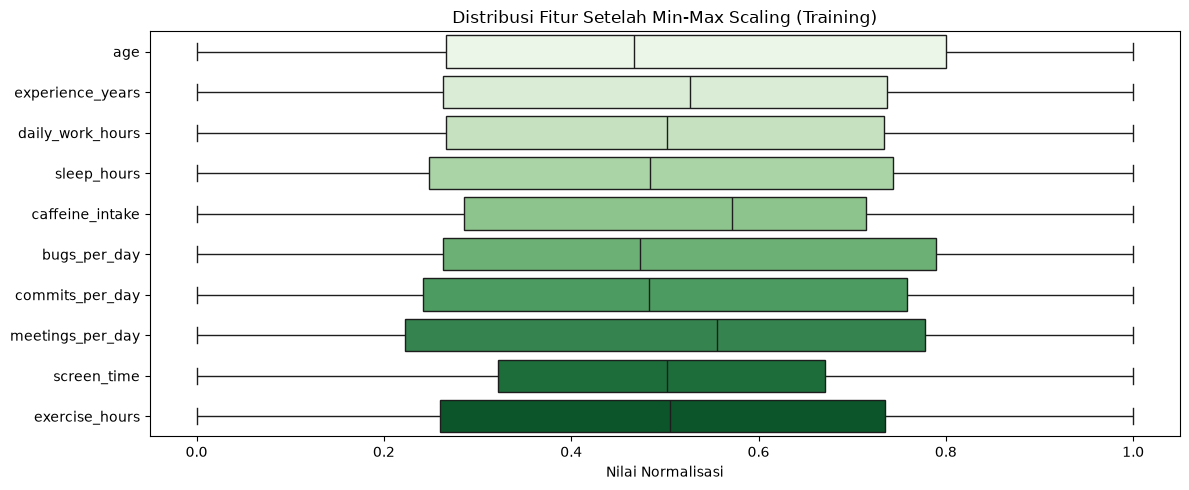

NORMALISASI SELESAI


In [ ]:
# ==========================================================
# NORMALISASI DATA (MIN-MAX SCALING)
# ==========================================================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("NORMALISASI DATA (MIN-MAX SCALING)")
print("="*60)

# ==========================================================
# MEMBACA DATA HASIL HANDLING MISSING VALUE
# ==========================================================

train = pd.read_csv("../hasil/1_data_training_bersih.csv")
test  = pd.read_csv("../hasil/1_data_testing_bersih.csv")

print("\nData Training :", train.shape)
print("Data Testing  :", test.shape)

# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print("\nMissing Value Training")
print(train.isnull().sum())

print("\nMissing Value Testing")
print(test.isnull().sum())

print("\nTotal NaN Training :", train.isnull().sum().sum())
print("Total NaN Testing  :", test.isnull().sum().sum())

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = train.drop(columns=["burnout_level"])
X_test  = test.drop(columns=["burnout_level"])

y_train = train["burnout_level"]
y_test  = test["burnout_level"]

print("\nJumlah Fitur :", X_train.shape[1])

# ==========================================================
# NORMALISASI MIN-MAX
# ==========================================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================================================
# KEMBALI MENJADI DATAFRAME
# ==========================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# ==========================================================
# GABUNGKAN KEMBALI TARGET
# ==========================================================

train_normal = X_train_scaled.copy()
train_normal["burnout_level"] = y_train.values

test_normal = X_test_scaled.copy()
test_normal["burnout_level"] = y_test.values

# ==========================================================
# CEK LAGI MISSING VALUE
# ==========================================================

print("\nMissing Value Setelah Normalisasi (Training)")
print(train_normal.isnull().sum())

print("\nMissing Value Setelah Normalisasi (Testing)")
print(test_normal.isnull().sum())

print("\nTotal NaN Training :", train_normal.isnull().sum().sum())
print("Total NaN Testing  :", test_normal.isnull().sum().sum())

# ==========================================================
# SIMPAN
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

train_normal.to_csv(
    "../hasil/2_data_setelah_normalisasi_train.csv",
    index=False
)

test_normal.to_csv(
    "../hasil/2_data_setelah_normalisasi_test.csv",
    index=False
)

print("\nData berhasil disimpan")

print("../hasil/2_data_setelah_normalisasi_train.csv")
print("../hasil/2_data_setelah_normalisasi_test.csv")

# ==========================================================
# VERIFIKASI
# ==========================================================

print("\nNilai Minimum Training")
print(X_train_scaled.min())

print("\nNilai Maksimum Training")
print(X_train_scaled.max())

print("\n5 Data Pertama Training")
print(train_normal.head())

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=X_train_scaled,
    orient="h",
    palette="Greens"
)

plt.title("Distribusi Fitur Setelah Min-Max Scaling (Training)")
plt.xlabel("Nilai Normalisasi")
plt.xlim(-0.05,1.05)

plt.tight_layout()
plt.show()

print("="*60)
print("NORMALISASI SELESAI")
print("="*60)

## 4. Label Encoding (Target)

LABEL ENCODING DATA TARGET

Isi unik target sebelum encoding
Train :
<ArrowStringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str

Test :
<ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

Mapping Label
Low      --> 0
Medium   --> 1
High     --> 2
------------------------------------------------------------
Label unik training
[0 1 2]

Label unik testing
[0 1 2]
------------------------------------------------------------
Data train berhasil disimpan
Data test berhasil disimpan

Distribusi Target
0 (Low) : 801 data
1 (Medium) : 1766 data
2 (High) : 895 data


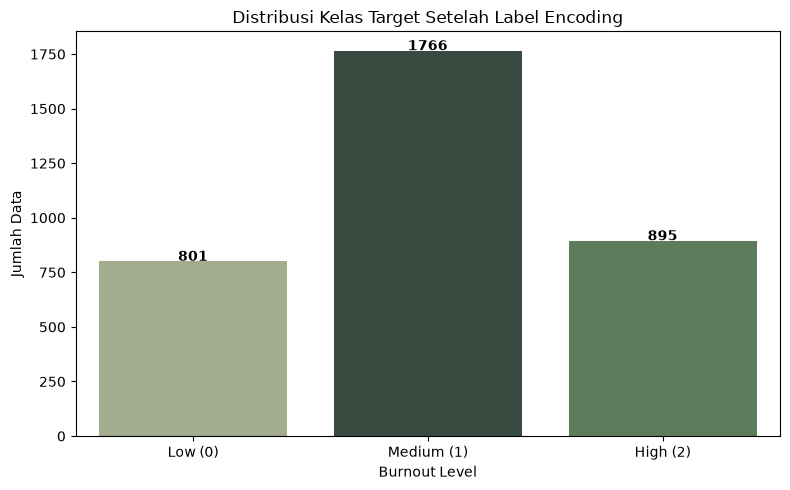

LABEL ENCODING BERHASIL


In [ ]:
# ==========================================================
# LABEL ENCODING DATA TARGET
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("LABEL ENCODING DATA TARGET")
print("="*60)

# ==========================================================
# LOAD DATA
# ==========================================================

df_train = pd.read_csv("../hasil/2_data_setelah_normalisasi_train.csv")
df_test  = pd.read_csv("../hasil/2_data_setelah_normalisasi_test.csv")

target = "burnout_level"

# ==========================================================
# CEK TARGET
# ==========================================================

print("\nIsi unik target sebelum encoding")

print("Train :")
print(df_train[target].unique())

print("\nTest :")
print(df_test[target].unique())

# ==========================================================
# BERSIHKAN STRING
# ==========================================================

df_train[target] = (
    df_train[target]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

df_test[target] = (
    df_test[target]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

# ==========================================================
# MAPPING
# ==========================================================

mapping = {
    "Low":0,
    "Medium":1,
    "High":2
}

df_train[target] = df_train[target].map(mapping)
df_test[target]  = df_test[target].map(mapping)

# ==========================================================
# HAPUS BARIS YANG GAGAL DIENCODE
# ==========================================================

df_train = df_train[df_train[target].isin([0,1,2])].reset_index(drop=True)
df_test  = df_test[df_test[target].isin([0,1,2])].reset_index(drop=True)

# ==========================================================
# UBAH KE INTEGER
# ==========================================================

df_train[target] = df_train[target].astype(int)
df_test[target] = df_test[target].astype(int)

# ==========================================================
# PISAH FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=[target])
X_test = df_test.drop(columns=[target])

y_train = df_train[target]
y_test = df_test[target]

# ==========================================================
# INFORMASI
# ==========================================================

print("\nMapping Label")

for k,v in mapping.items():
    print(f"{k:<8} --> {v}")

print("-"*60)

print("Label unik training")
print(np.unique(y_train))

print()

print("Label unik testing")
print(np.unique(y_test))

print("-"*60)

# ==========================================================
# SIMPAN
# ==========================================================

os.makedirs("../hasil",exist_ok=True)

df_train.to_csv("../hasil/4_data_train_encoded.csv",index=False)
df_test.to_csv("../hasil/4_data_test_encoded.csv",index=False)

print("Data train berhasil disimpan")
print("Data test berhasil disimpan")

# ==========================================================
# DISTRIBUSI TARGET
# ==========================================================

print("\nDistribusi Target")

kelas = {
    0:"Low",
    1:"Medium",
    2:"High"
}

for i in sorted(y_train.unique()):

    print(f"{i} ({kelas[i]}) : {(y_train==i).sum()} data")

# ==========================================================
# VISUALISASI
# ==========================================================

plot_df = pd.DataFrame({
    "Burnout Level":y_train.map({
        0:"Low (0)",
        1:"Medium (1)",
        2:"High (2)"
    })
})

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=plot_df,
    x="Burnout Level",
    order=["Low (0)","Medium (1)","High (2)"],
    hue="Burnout Level",
    palette=["#A3B18A","#588157","#344E41"],
    legend=False
)

for p in ax.patches:

    h = p.get_height()

    ax.annotate(
        str(int(h)),
        (p.get_x()+p.get_width()/2,h+2),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Distribusi Kelas Target Setelah Label Encoding")
plt.xlabel("Burnout Level")
plt.ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

print("="*60)
print("LABEL ENCODING BERHASIL")
print("="*60)

In [ ]:
print("\n===== CEK MISSING VALUE SETELAH NORMALISASI =====")

print("\nTraining")
print(df_train.isnull().sum())
print("Total :", df_train.isnull().sum().sum())

print("\nTesting")
print(df_test.isnull().sum())
print("Total :", df_test.isnull().sum().sum())


===== CEK MISSING VALUE SETELAH NORMALISASI =====

Training
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64
Total : 0

Testing
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
burnout_level       0
dtype: int64
Total : 0


## Implementasi Klasifikasi dengan Algoritma Random Forest Sebelum DI SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

IMPLEMENTASI RANDOM FOREST SEBELUM SMOTE

Jumlah Data Training : 3462
Jumlah Data Testing  : 866
Jumlah Fitur : 10
------------------------------------------------------------
Model Random Forest berhasil dibuat
Model berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 75.52 %
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

           0     0.7874    0.6816    0.7307       201
           1     0.7567    0.8229    0.7884       480
           2     0.7176    0.6595    0.6873       185

    accuracy                         0.7552       866
   macro avg     0.7539    0.7213    0.7355       866
weighted avg     0.7555    0.7552    0.7534       866

------------------------------------------------------------
Confusion Matrix
               Pred Low  Pred Medium  Pred High
Actual Low      

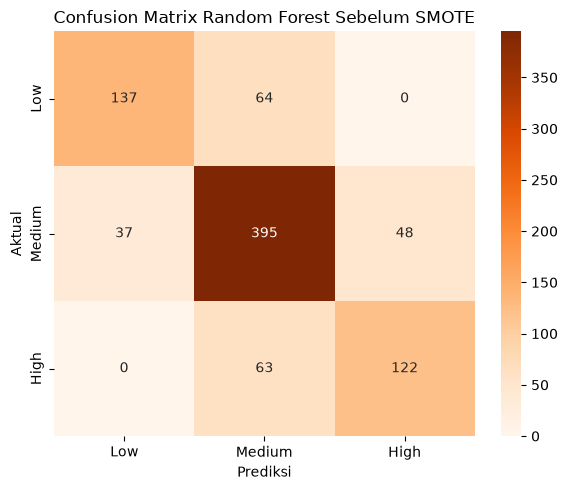

SELESAI


In [ ]:
# ==========================================================
# RANDOM FOREST SEBELUM SMOTE
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("IMPLEMENTASI RANDOM FOREST SEBELUM SMOTE")
print("="*60)

# ==========================================================
# MEMBACA DATA HASIL LABEL ENCODING
# ==========================================================

train = pd.read_csv("../hasil/4_data_train_encoded.csv")
test = pd.read_csv("../hasil/4_data_test_encoded.csv")

target = "burnout_level"

# ==========================================================
# PISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("\nJumlah Data Training :", len(train))
print("Jumlah Data Testing  :", len(test))

print("Jumlah Fitur :", X_train.shape[1])

print("-"*60)

# ==========================================================
# MEMBUAT MODEL RANDOM FOREST
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Model Random Forest berhasil dibuat")

# ==========================================================
# TRAINING
# ==========================================================

rf_model.fit(X_train, y_train)

print("Model berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred = rf_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

akurasi = accuracy_score(y_test, y_pred)

print("Accuracy :", round(akurasi*100,2),"%")

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test,y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low","Actual Medium","Actual High"],
    columns=["Pred Low","Pred Medium","Pred High"]
)

print("Confusion Matrix")

print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Confusion Matrix Random Forest Sebelum SMOTE")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()

plt.show()

print("="*60)
print("SELESAI")
print("="*60)

## Implementasi Klasifikasi dengan Algoritma XGBoost Sebelum Di SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

IMPLEMENTASI XGBOOST SEBELUM SMOTE

Jumlah Data Training : 3462
Jumlah Data Testing  : 866
Jumlah Fitur : 10
------------------------------------------------------------
Model XGBoost berhasil dibuat
------------------------------------------------------------
Model berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Akurasi : 75.98%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low     0.7637    0.6915    0.7258       201
      Medium     0.7688    0.8104    0.7890       480
        High     0.7303    0.7027    0.7163       185

    accuracy                         0.7598       866
   macro avg     0.7543    0.7349    0.7437       866
weighted avg     0.7594    0.7598    0.7588       866

------------------------------------------------------------
               Prediksi Low  Predi

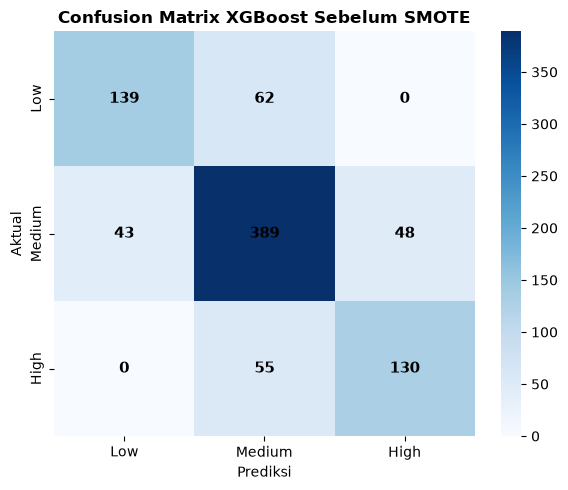

IMPLEMENTASI XGBOOST SEBELUM SMOTE SELESAI


In [ ]:
# ==========================================================
# IMPLEMENTASI XGBOOST SEBELUM SMOTE
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("IMPLEMENTASI XGBOOST SEBELUM SMOTE")
print("="*60)

# ==========================================================
# MEMBACA DATA
# ==========================================================

train = pd.read_csv("../hasil/4_data_train_encoded.csv")
test = pd.read_csv("../hasil/4_data_test_encoded.csv")

target = "burnout_level"

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("\nJumlah Data Training :", len(train))
print("Jumlah Data Testing  :", len(test))
print("Jumlah Fitur :", X_train.shape[1])

print("-"*60)

# ==========================================================
# MEMBUAT MODEL XGBOOST
# ==========================================================

xgb_model = XGBClassifier(

    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,

    objective="multi:softmax",
    num_class=3,

    eval_metric="mlogloss",

    random_state=42
)

print("Model XGBoost berhasil dibuat")

print("-"*60)

# ==========================================================
# TRAINING
# ==========================================================

xgb_model.fit(X_train, y_train)

print("Model berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred = xgb_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

akurasi = accuracy_score(y_test, y_pred)

print(f"Akurasi : {akurasi*100:.2f}%")

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low","Medium","High"],
    digits=4
))

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(
    cm,
    columns=[
        "Prediksi Low",
        "Prediksi Medium",
        "Prediksi High"
    ],
    index=[
        "Aktual Low",
        "Aktual Medium",
        "Aktual High"
    ]
)

print(df_cm)

print("-"*60)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"],
    annot_kws={
        "size":11,
        "weight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix XGBoost Sebelum SMOTE",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("IMPLEMENTASI XGBOOST SEBELUM SMOTE SELESAI")
print("="*60)

## Implementasi Klasifikasi dengan Algoritma Support Vector Machine (SVM) Sebelum DI SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

In [ ]:
print("===== CEK MISSING VALUE =====")

print(X_train.isnull().sum())

print()

print("Total NaN Training :", X_train.isnull().sum().sum())

print()

print(X_test.isnull().sum())

print()

print("Total NaN Testing :", X_test.isnull().sum().sum())

===== CEK MISSING VALUE =====
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
dtype: int64

Total NaN Training : 0

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
dtype: int64

Total NaN Testing : 0


IMPLEMENTASI SVM SEBELUM SMOTE

Jumlah Data Training : 3462
Jumlah Data Testing  : 866
Jumlah Fitur : 10
------------------------------------------------------------
Model SVM berhasil dibuat
------------------------------------------------------------
Model berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Akurasi : 79.33%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low     0.7926    0.7413    0.7661       201
      Medium     0.7992    0.8375    0.8179       480
        High     0.7771    0.7351    0.7556       185

    accuracy                         0.7933       866
   macro avg     0.7896    0.7713    0.7798       866
weighted avg     0.7929    0.7933    0.7926       866

------------------------------------------------------------
               Prediksi Low  Prediksi Medi

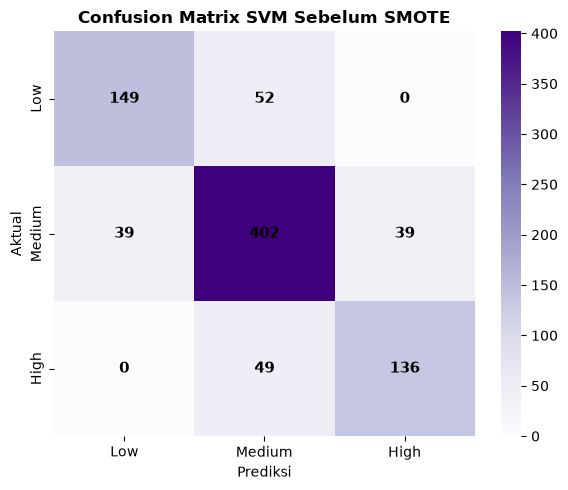

IMPLEMENTASI SVM SEBELUM SMOTE SELESAI


In [ ]:
# ==========================================================
# IMPLEMENTASI SVM SEBELUM SMOTE
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("IMPLEMENTASI SVM SEBELUM SMOTE")
print("="*60)

# ==========================================================
# MEMBACA DATA
# ==========================================================

train = pd.read_csv("../hasil/4_data_train_encoded.csv")
test = pd.read_csv("../hasil/4_data_test_encoded.csv")

target = "burnout_level"

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("\nJumlah Data Training :", len(train))
print("Jumlah Data Testing  :", len(test))
print("Jumlah Fitur :", X_train.shape[1])

print("-"*60)

# ==========================================================
# MEMBUAT MODEL SVM
# ==========================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

print("Model SVM berhasil dibuat")

print("-"*60)

# ==========================================================
# TRAINING
# ==========================================================

svm_model.fit(X_train, y_train)

print("Model berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred = svm_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

akurasi = accuracy_score(y_test, y_pred)

print(f"Akurasi : {akurasi*100:.2f}%")

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low","Medium","High"],
    digits=4
))

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(
    cm,
    index=[
        "Aktual Low",
        "Aktual Medium",
        "Aktual High"
    ],
    columns=[
        "Prediksi Low",
        "Prediksi Medium",
        "Prediksi High"
    ]
)

print(df_cm)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"],
    cbar=True,
    annot_kws={
        "size":11,
        "weight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix SVM Sebelum SMOTE",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("IMPLEMENTASI SVM SEBELUM SMOTE SELESAI")
print("="*60)

## SMOTE

SMOTE (OVERSAMPLING DATA TRAINING)

Distribusi Sebelum SMOTE
burnout_level
0     801
1    1766
2     895
Name: count, dtype: int64

Total Data Training : 3462

SMOTE Berhasil

Distribusi Setelah SMOTE
burnout_level
0    1766
1    1766
2    1766
Name: count, dtype: int64

Jumlah Data Setelah SMOTE : 5298

Missing Value Setelah SMOTE
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
dtype: int64

Total NaN :
0

Data hasil SMOTE berhasil disimpan
../hasil/5_data_training_smote.csv


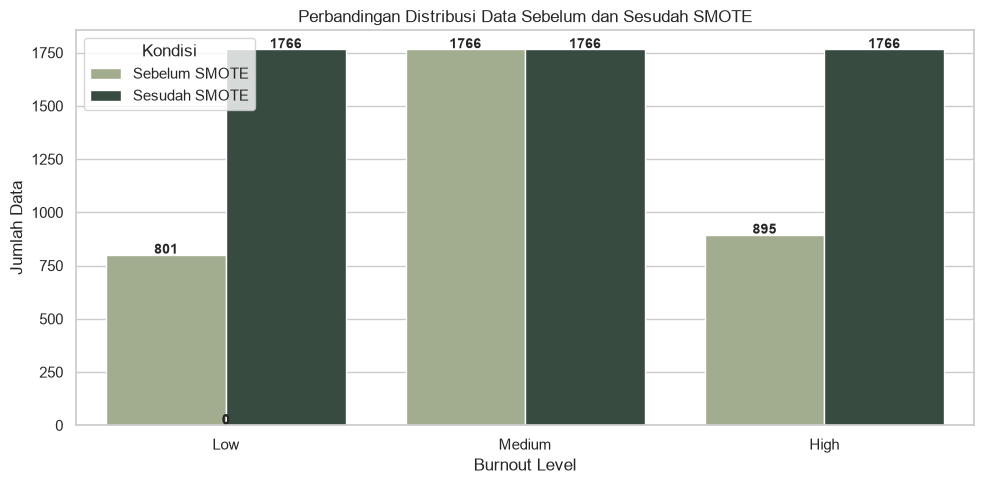

SMOTE SELESAI


In [ ]:
# ==========================================================
# SMOTE (OVERSAMPLING DATA TRAINING)
# ==========================================================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

print("="*60)
print("SMOTE (OVERSAMPLING DATA TRAINING)")
print("="*60)

# ==========================================================
# LOAD DATA HASIL LABEL ENCODING
# ==========================================================

df_train = pd.read_csv("../hasil/4_data_train_encoded.csv")
df_test  = pd.read_csv("../hasil/4_data_test_encoded.csv")

# ==========================================================
# PISAH FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

# ==========================================================
# DISTRIBUSI SEBELUM SMOTE
# ==========================================================

print("\nDistribusi Sebelum SMOTE")

counts_before = y_train.value_counts().sort_index()

print(counts_before)

print("\nTotal Data Training :", len(y_train))

# ==========================================================
# SMOTE
# ==========================================================

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("\nSMOTE Berhasil")

# ==========================================================
# DISTRIBUSI SESUDAH SMOTE
# ==========================================================

counts_after = y_train_resampled.value_counts().sort_index()

print("\nDistribusi Setelah SMOTE")

print(counts_after)

print("\nJumlah Data Setelah SMOTE :", len(y_train_resampled))

# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print("\nMissing Value Setelah SMOTE")

print(pd.DataFrame(X_train_resampled).isnull().sum())

print("\nTotal NaN :")

print(pd.DataFrame(X_train_resampled).isnull().sum().sum())

# ==========================================================
# SIMPAN DATA TRAIN HASIL SMOTE
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

df_smote = pd.DataFrame(
    X_train_resampled,
    columns=X_train.columns
)

df_smote["burnout_level"] = y_train_resampled.values

df_smote.to_csv(
    "../hasil/5_data_training_smote.csv",
    index=False
)

print("\nData hasil SMOTE berhasil disimpan")

print("../hasil/5_data_training_smote.csv")

# ==========================================================
# VISUALISASI
# ==========================================================

before = pd.DataFrame({
    "Kelas":["Low","Medium","High"],
    "Jumlah":counts_before.values,
    "Kondisi":"Sebelum SMOTE"
})

after = pd.DataFrame({
    "Kelas":["Low","Medium","High"],
    "Jumlah":counts_after.values,
    "Kondisi":"Sesudah SMOTE"
})

visual = pd.concat([before,after])

plt.figure(figsize=(10,5))

sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=visual,
    x="Kelas",
    y="Jumlah",
    hue="Kondisi",
    palette=["#A3B18A","#344E41"]
)

for p in ax.patches:

    tinggi = p.get_height()

    ax.annotate(
        f"{int(tinggi)}",
        (
            p.get_x()+p.get_width()/2,
            tinggi+5
        ),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Perbandingan Distribusi Data Sebelum dan Sesudah SMOTE")
plt.xlabel("Burnout Level")
plt.ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

print("="*60)
print("SMOTE SELESAI")
print("="*60)

## Implementasi Klasifikasi dengan Algoritma Random Forest Setelah DI SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

MODEL RANDOM FOREST (SETELAH SMOTE)

Jumlah Data Training : (5298, 10)
Jumlah Data Testing  : (866, 10)

Total NaN Training : 0
Total NaN Testing  : 0

Model Random Forest berhasil dilatih.
Prediksi berhasil dilakukan.

Accuracy : 75.17 %

Classification Report
              precision    recall  f1-score   support

         Low       0.71      0.78      0.74       201
      Medium       0.80      0.74      0.77       480
        High       0.70      0.75      0.72       185

    accuracy                           0.75       866
   macro avg       0.73      0.76      0.74       866
weighted avg       0.75      0.75      0.75       866


Confusion Matrix
               Pred Low  Pred Medium  Pred High
Actual Low          156           45          0
Actual Medium        63          357         60
Actual High           0           47        138


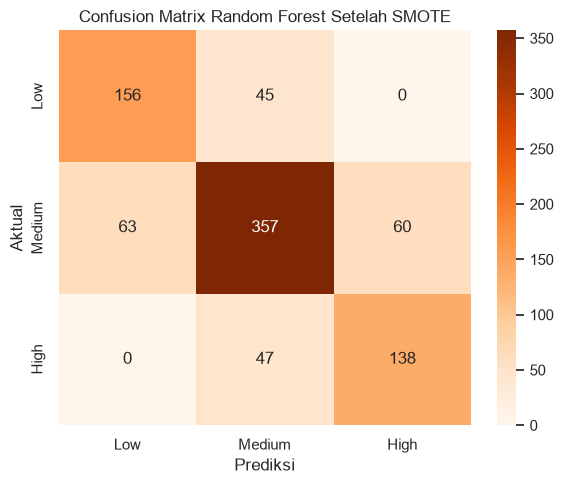

RANDOM FOREST SELESAI


In [ ]:
# ==========================================================
# RANDOM FOREST (SETELAH SMOTE)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("MODEL RANDOM FOREST (SETELAH SMOTE)")
print("="*60)

# ==========================================================
# MEMBACA DATA
# ==========================================================

df_train = pd.read_csv("../hasil/5_data_training_smote.csv")
df_test  = pd.read_csv("../hasil/4_data_test_encoded.csv")

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

print("\nJumlah Data Training :", X_train.shape)
print("Jumlah Data Testing  :", X_test.shape)

# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print("\nTotal NaN Training :", X_train.isnull().sum().sum())
print("Total NaN Testing  :", X_test.isnull().sum().sum())

# ==========================================================
# MEMBUAT MODEL RANDOM FOREST
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# ==========================================================
# TRAINING MODEL
# ==========================================================

rf_model.fit(X_train, y_train)

print("\nModel Random Forest berhasil dilatih.")

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred = rf_model.predict(X_test)

print("Prediksi berhasil dilakukan.")

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", round(accuracy*100,2), "%")

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Low","Medium","High"]
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test,y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low","Actual Medium","Actual High"],
    columns=["Pred Low","Pred Medium","Pred High"]
)

print("\nConfusion Matrix")

print(cm_df)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Confusion Matrix Random Forest Setelah SMOTE")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("RANDOM FOREST SELESAI")
print("="*60)

## Implementasi Klasifikasi dengan Algoritma XGBoost Setelah Di SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

Model XGBoost berhasil dilatih menggunakan data hasil SMOTE
------------------------------------------------------------


PERHITUNGAN MANUAL XGBOOST (2 DATA SAMPEL)

Dataset yang digunakan
5_data_testing.csv

Data diambil dari
Baris ke-1 dan Baris ke-2 pada dataset testing

Data Sampel 1
age                 0.800000
experience_years    0.526316
daily_work_hours    0.449000
sleep_hours         0.922000
caffeine_intake     0.285714
bugs_per_day        0.526316
commits_per_day     0.586207
meetings_per_day    0.888889
screen_time         0.556877
exercise_hours      0.510000
Name: 0, dtype: float64

Label Aktual : 1

Data Sampel 2
age                 0.266667
experience_years    0.052632
daily_work_hours    0.339000
sleep_hours         0.606000
caffeine_intake     0.000000
bugs_per_day        0.052632
commits_per_day     0.310345
meetings_per_day    0.000000
screen_time         0.405948
exercise_hours      0.565000
Name: 1, dtype: float64

Label Aktual : 0


-----------------------------

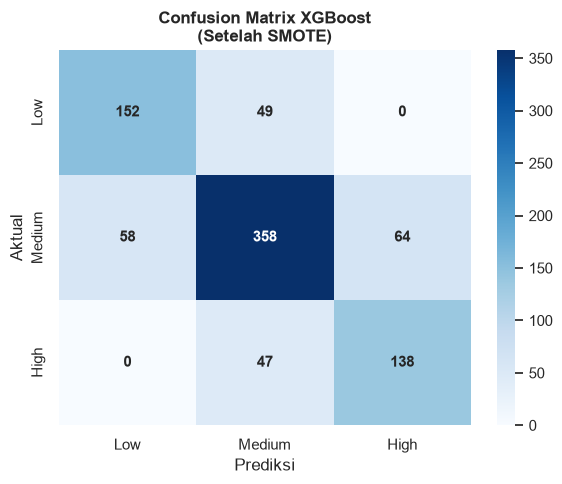

XGBOOST SELESAI


In [ ]:
# ==========================================================
# TRAINING
# ==========================================================

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Model XGBoost berhasil dilatih menggunakan data hasil SMOTE")

print("-"*60)

# ==========================================================
# PERHITUNGAN MANUAL 2 DATA SAMPEL XGBOOST
# ==========================================================

import numpy as np

print("\n")
print("="*60)
print("PERHITUNGAN MANUAL XGBOOST (2 DATA SAMPEL)")
print("="*60)

print("\nDataset yang digunakan")
print("5_data_testing.csv")

print("\nData diambil dari")
print("Baris ke-1 dan Baris ke-2 pada dataset testing")

# ----------------------------------------------------------
# Ambil 2 data pertama
# ----------------------------------------------------------

data1 = X_test.iloc[0]
data2 = X_test.iloc[1]

label1 = y_test.iloc[0]
label2 = y_test.iloc[1]

print("\nData Sampel 1")
print(data1)

print("\nLabel Aktual :", label1)

print("\nData Sampel 2")
print(data2)

print("\nLabel Aktual :", label2)

# ----------------------------------------------------------
# Prediksi awal (base score)
# ----------------------------------------------------------

base_score = xgb_model.get_xgb_params().get("base_score",0.5)

print("\n")
print("-"*60)
print("1. Prediksi Awal (Base Score)")
print("-"*60)

print("Base Score =",base_score)

# ----------------------------------------------------------
# Probabilitas tiap kelas
# ----------------------------------------------------------

prob = xgb_model.predict_proba(
    X_test.iloc[:2]
)

print("\n")
print("-"*60)
print("2. Probabilitas Setiap Kelas")
print("-"*60)

kelas=["Low","Medium","High"]

for i in range(2):

    print(f"\nData {i+1}")

    for j in range(3):

        print(
            kelas[j],
            "=",
            round(prob[i][j],6)
        )

# ----------------------------------------------------------
# Nilai tertinggi
# ----------------------------------------------------------

print("\n")
print("-"*60)
print("3. Menentukan Nilai Probabilitas Terbesar")
print("-"*60)

for i in range(2):

    maksimum=np.max(prob[i])

    indeks=np.argmax(prob[i])

    print(
        f"Data {i+1} :",
        round(maksimum,6),
        "->",
        kelas[indeks]
    )

# ----------------------------------------------------------
# Prediksi akhir
# ----------------------------------------------------------

prediksi = xgb_model.predict(
    X_test.iloc[:2]
)

print("\n")
print("-"*60)
print("4. Prediksi Akhir")
print("-"*60)

for i,p in enumerate(prediksi):

    if p==0:
        hasil="Low"

    elif p==1:
        hasil="Medium"

    else:
        hasil="High"

    print(
        "Data",
        i+1,
        "=",
        hasil,
        "(",
        p,
        ")"
    )

# ----------------------------------------------------------
# Evaluasi
# ----------------------------------------------------------

print("\n")
print("-"*60)
print("5. Evaluasi Hasil")
print("-"*60)

for i in range(2):

    if prediksi[i]==y_test.iloc[i]:

        status="Prediksi Benar"

    else:

        status="Prediksi Salah"

    print(
        "Data",
        i+1,
        ":",
        status
    )

print("\nKesimpulan")

print("Data Sampel 1 diprediksi sebagai",kelas[prediksi[0]])
print("Data Sampel 2 diprediksi sebagai",kelas[prediksi[1]])
print("Perhitungan manual menunjukkan bagaimana XGBoost memilih kelas berdasarkan probabilitas terbesar dari setiap data uji.")

print("="*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_xgb = xgb_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")
print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    }
)

plt.title(
    "Confusion Matrix XGBoost\n(Setelah SMOTE)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("XGBOOST SELESAI")
print("="*60)

## Implementasi Klasifikasi dengan Algoritma Support Vector Machine (SVM) Setelah di SMOTE
### Proses Pelatihan Model (Training Process)
### Hasil Klasifikasi dan Evaluasi Kinerja Model
### Analisis Kinerja Model

SUPPORT VECTOR MACHINE (SETELAH SMOTE)

Ukuran Data
X_train_resampled : (5298, 10)
y_train_resampled : (5298,)
X_test : (866, 10)
y_test : (866,)
------------------------------------------------------------
Model SVM berhasil dilatih menggunakan data hasil SMOTE
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 77.02%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.71      0.83      0.76       201
      Medium       0.85      0.72      0.78       480
        High       0.70      0.85      0.77       185

    accuracy                           0.77       866
   macro avg       0.75      0.80      0.77       866
weighted avg       0.78      0.77      0.77       866

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict 

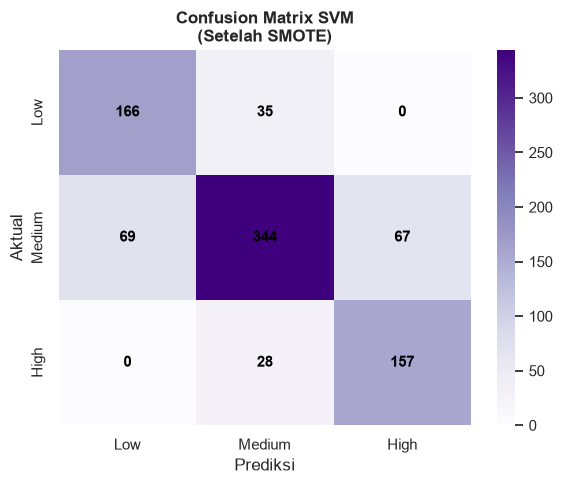

SVM SELESAI


In [ ]:
# ==========================================================
# SUPPORT VECTOR MACHINE (SETELAH SMOTE)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("SUPPORT VECTOR MACHINE (SETELAH SMOTE)")
print("="*60)

# ==========================================================
# CEK DATA
# ==========================================================

print("\nUkuran Data")

print("X_train_resampled :", X_train_resampled.shape)
print("y_train_resampled :", y_train_resampled.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

# ==========================================================
# TRAINING
# ==========================================================

svm_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Model SVM berhasil dilatih menggunakan data hasil SMOTE")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_svm = svm_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")
print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix SVM\n(Setelah SMOTE)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("SVM SELESAI")
print("="*60)

## Perbandingan Kinerja Model

PERBANDINGAN AKURASI MODEL
    Algoritma  Akurasi (%)
          SVM    77.020785
Random Forest    75.173210
      XGBoost    74.826790


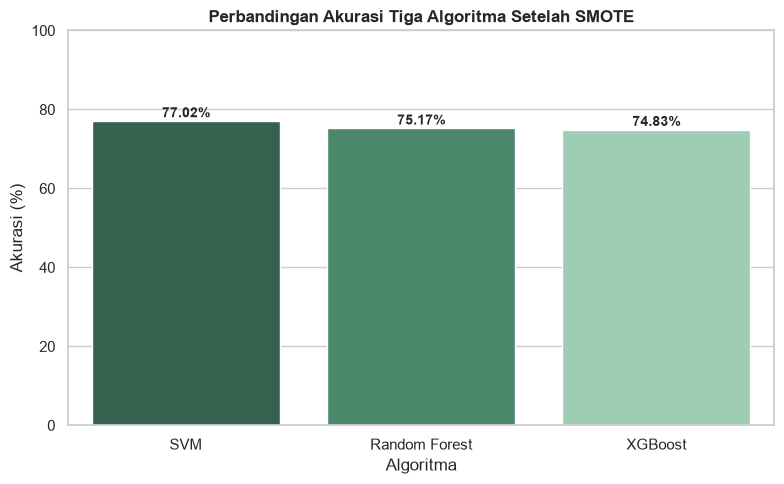

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

# ==========================================================
# HITUNG AKURASI MASING-MASING MODEL
# ==========================================================

# Random Forest
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100

# SVM
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm) * 100


# ==========================================================
# TABEL PERBANDINGAN AKURASI
# ==========================================================

hasil = pd.DataFrame({
    "Algoritma": [
        "Random Forest",
        "XGBoost",
        "SVM"
    ],
    "Akurasi (%)": [
        acc_rf,
        acc_xgb,
        acc_svm
    ]
})

# Urutkan berdasarkan akurasi terbesar
hasil = hasil.sort_values(
    by="Akurasi (%)",
    ascending=False
).reset_index(drop=True)

print("="*50)
print("PERBANDINGAN AKURASI MODEL")
print("="*50)
print(hasil.to_string(index=False))


# ==========================================================
# VISUALISASI GRAFIK
# ==========================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=hasil,
    x="Algoritma",
    y="Akurasi (%)",
    hue="Algoritma",
    palette=["#2D6A4F", "#40916C", "#95D5B2"],
    legend=False
)

# Menampilkan angka di atas batang
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 1
        ),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Perbandingan Akurasi Tiga Algoritma Setelah SMOTE",
    fontsize=12,
    fontweight='bold'
)

plt.xlabel("Algoritma")
plt.ylabel("Akurasi (%)")
plt.ylim(0,100)

plt.tight_layout()
plt.show()

## Tabel perbandingan per baris (Data Aktual vs Hasil Prediksi)

In [ ]:
import pandas as pd
from IPython.display import display

# ==========================================================
# PREDIKSI MODEL (jika belum dibuat)
# ==========================================================

y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# ==========================================================
# KONVERSI AGAR INDEKS AMAN
# ==========================================================

y_test_list = list(y_test)
y_pred_rf = list(y_pred_rf)
y_pred_xgb = list(y_pred_xgb)
y_pred_svm = list(y_pred_svm)

# Maksimal tampil 20 data
n_samples = min(20, len(y_test_list))

# ==========================================================
# MEMBUAT TABEL EVALUASI
# ==========================================================

tabel_evaluasi = pd.DataFrame({
    'No': range(1, n_samples + 1),
    'Data Aktual (y_test)': y_test_list[:n_samples],
    'Prediksi Random Forest': y_pred_rf[:n_samples],
    'Prediksi XGBoost': y_pred_xgb[:n_samples],
    'Prediksi SVM': y_pred_svm[:n_samples]
})

# ==========================================================
# FUNGSI STATUS EVALUASI
# ==========================================================

def cek_status(row):
    
    aktual = row['Data Aktual (y_test)']
    rf = row['Prediksi Random Forest']
    xgb = row['Prediksi XGBoost']
    svm = row['Prediksi SVM']

    if aktual == rf == xgb == svm:
        return "Sesuai Sempurna"

    catatan = []

    if rf != aktual:
        catatan.append("RF Salah")

    if xgb != aktual:
        catatan.append("XGB Salah")

    if svm != aktual:
        catatan.append("SVM Salah")

    return ", ".join(catatan)

# Tambahkan kolom evaluasi
tabel_evaluasi['Status Evaluasi Sampel'] = tabel_evaluasi.apply(
    cek_status,
    axis=1
)

# ==========================================================
# TAMPILKAN HASIL
# ==========================================================

print("="*70)
print("TABEL DATA AKTUAL VS PREDIKSI (20 SAMPEL)")
print("="*70)

display(tabel_evaluasi)

TABEL DATA AKTUAL VS PREDIKSI (20 SAMPEL)


,No,Data Aktual (y_test),Prediksi Random Forest,Prediksi XGBoost,Prediksi SVM,Status Evaluasi Sampel
0,1,1,1,1,1,Sesuai Sempurna
1,2,0,0,0,0,Sesuai Sempurna
2,3,2,2,2,2,Sesuai Sempurna
3,4,2,1,1,1,"RF Salah, XGB Salah, SVM Salah"
4,5,0,0,0,0,Sesuai Sempurna
5,6,1,1,1,1,Sesuai Sempurna
6,7,1,1,0,1,XGB Salah
7,8,2,2,2,2,Sesuai Sempurna
8,9,1,0,0,0,"RF Salah, XGB Salah, SVM Salah"
9,10,1,1,1,1,Sesuai Sempurna
